## Cars lassification
- pytorch


In [92]:
#Verifico la capacidad de GPU
!nvidia-smi

Tue Jun  4 23:07:13 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.171.04             Driver Version: 535.171.04   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 2060        Off | 00000000:01:00.0 Off |                  N/A |
| N/A   51C    P8               6W /  80W |   1232MiB /  6144MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [93]:
#Librerias a importar
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, models, transforms


In [94]:
# Convertir nuestros datos a tensores
transform=transforms.Compose([transforms.RandomResizedCrop(224),
                              transforms. ToTensor(),
                              transforms.Normalize([0.485, 0.456, 0.406], # Imagenet 
                              [0.229, 0.224, 0.225])
                             ])

In [95]:
# Cargo los datos

train_dataset = datasets.ImageFolder(root='cars/train', transform=transform)
test_dataset = datasets.ImageFolder(root='cars/test', transform=transform)

In [96]:
# imprimo un resumen de los datos
print('Train:', len(train_dataset))

Train: 8144


In [97]:
batch_size = 4
learning_rate = 0.01
num_epocas = 1
step_log = 100

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                          batch_size = batch_size,
                                          shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                         batch_size = batch_size,
                                         shuffle=True)


Se visualiza 4 imágenes de un batch tomados de train_loader, se añade los datos de normalizacion para la correcta visualizacion de las imágenes

In [98]:
# Imprimo el nombre de las clases
class_names = train_dataset.classes
print(train_dataset.classes)

['AM General Hummer SUV 2000', 'Acura Integra Type R 2001', 'Acura RL Sedan 2012', 'Acura TL Sedan 2012', 'Acura TL Type-S 2008', 'Acura TSX Sedan 2012', 'Acura ZDX Hatchback 2012', 'Aston Martin V8 Vantage Convertible 2012', 'Aston Martin V8 Vantage Coupe 2012', 'Aston Martin Virage Convertible 2012', 'Aston Martin Virage Coupe 2012', 'Audi 100 Sedan 1994', 'Audi 100 Wagon 1994', 'Audi A5 Coupe 2012', 'Audi R8 Coupe 2012', 'Audi RS 4 Convertible 2008', 'Audi S4 Sedan 2007', 'Audi S4 Sedan 2012', 'Audi S5 Convertible 2012', 'Audi S5 Coupe 2012', 'Audi S6 Sedan 2011', 'Audi TT Hatchback 2011', 'Audi TT RS Coupe 2012', 'Audi TTS Coupe 2012', 'Audi V8 Sedan 1994', 'BMW 1 Series Convertible 2012', 'BMW 1 Series Coupe 2012', 'BMW 3 Series Sedan 2012', 'BMW 3 Series Wagon 2012', 'BMW 6 Series Convertible 2007', 'BMW ActiveHybrid 5 Sedan 2012', 'BMW M3 Coupe 2012', 'BMW M5 Sedan 2010', 'BMW M6 Convertible 2010', 'BMW X3 SUV 2012', 'BMW X5 SUV 2007', 'BMW X6 SUV 2012', 'BMW Z4 Convertible 2012

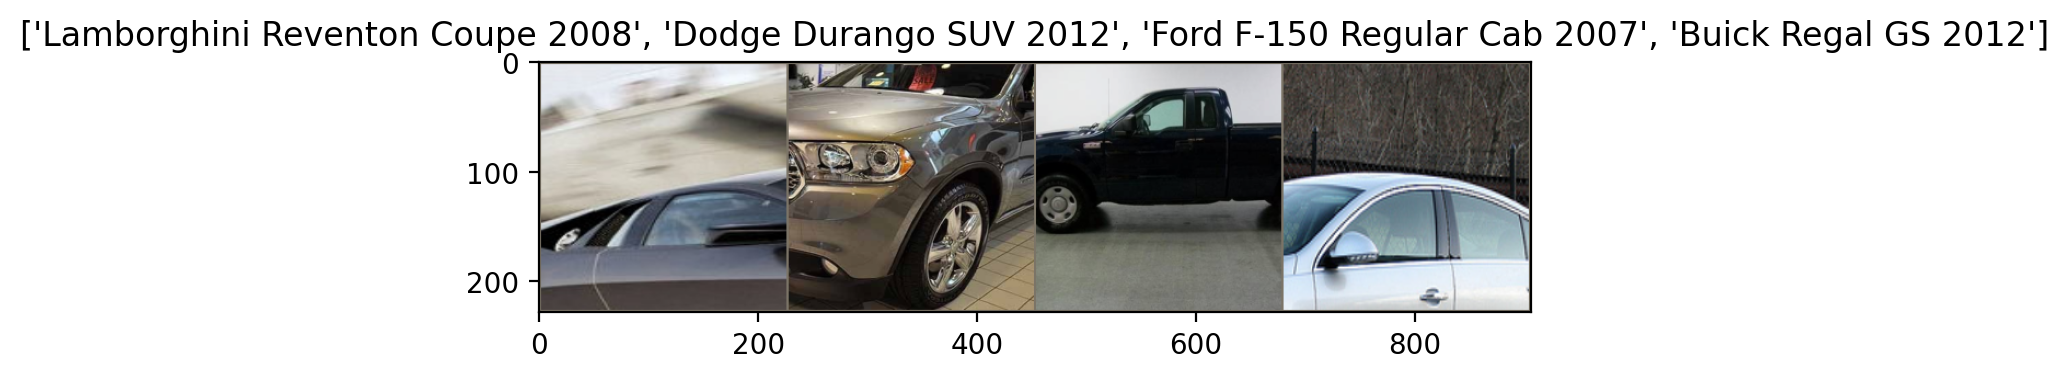

In [99]:
# Cargo un batch de imagenes

def imshow(inp, title = None):
  inp = inp.numpy().transpose((1, 2, 0))
  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])
  inp = std * inp + mean
  inp = np.clip(inp, 0, 1)
  plt.imshow(inp)
  
  if title is not None:
    plt.title(title)
  plt.pause(0.001)
  
dataiter = iter(train_loader)
inputs, classes = next(dataiter)

out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

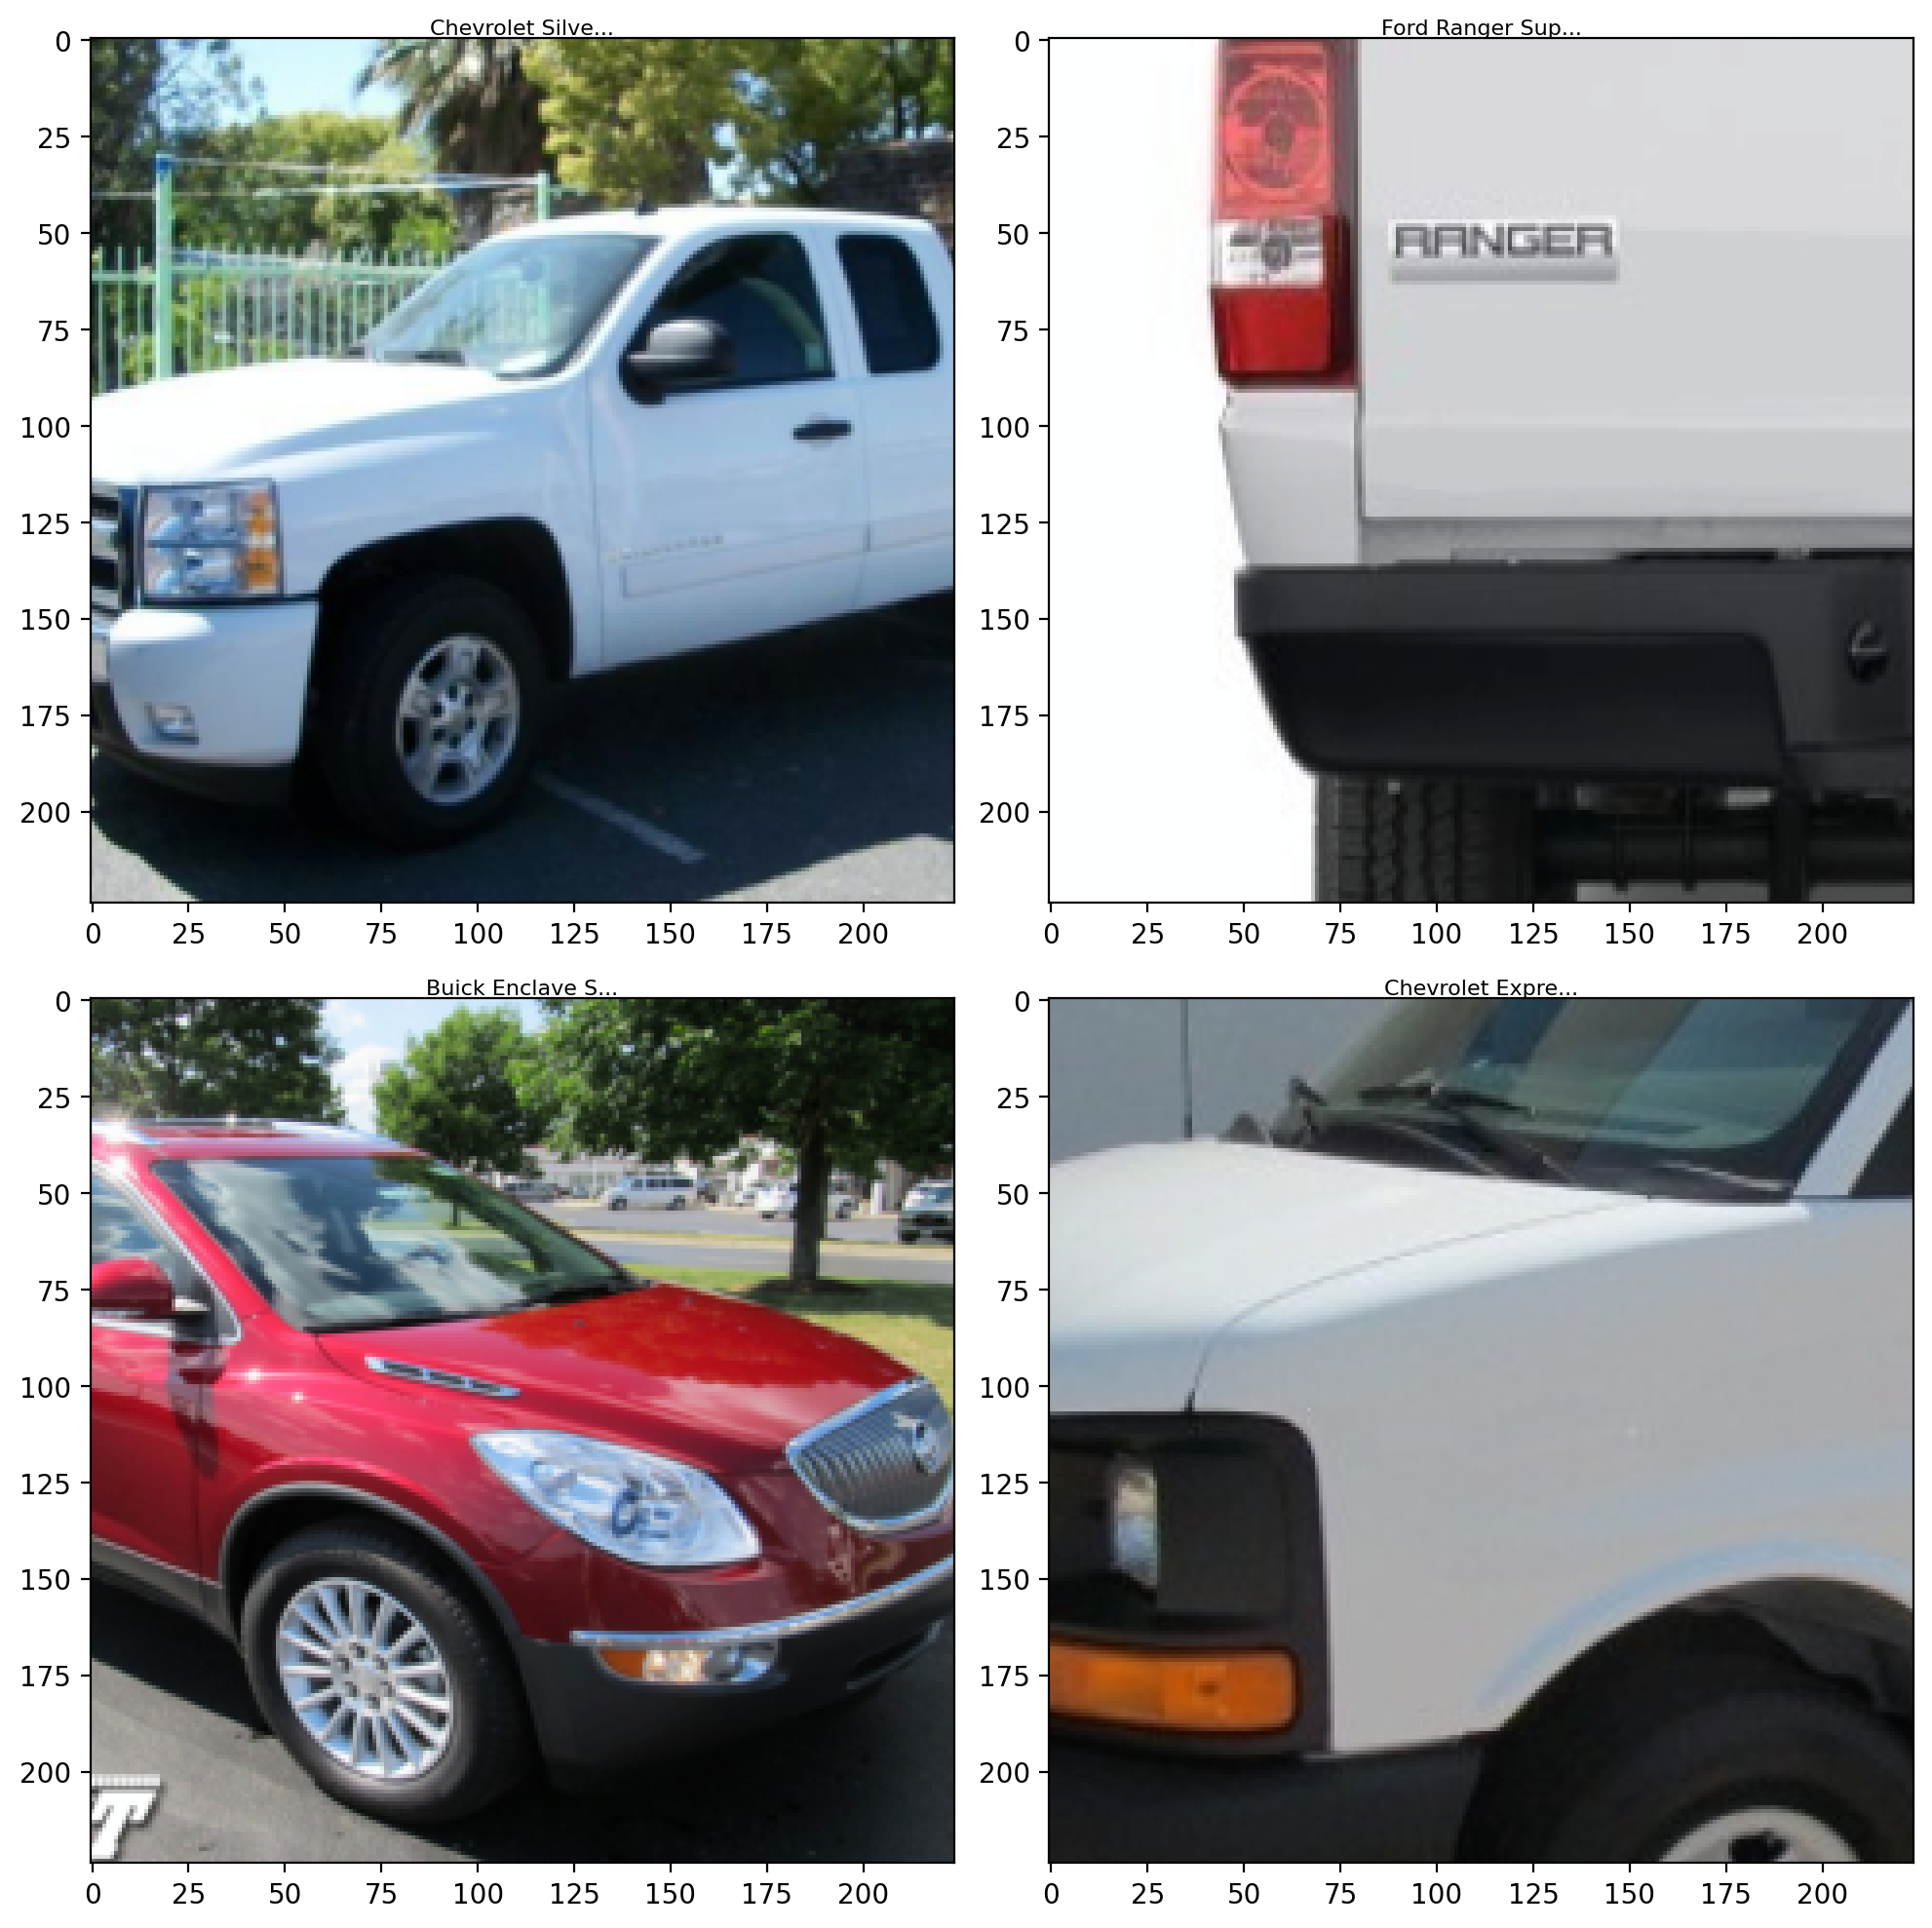

In [100]:
# Se grafican nuevamente, pero con los nombres de las clases truncados

def imshow_with_class_name(inp, class_name, ax=None):   
    
    if ax is None:
        ax = plt.gca()

    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    ax.imshow(inp)

      # Limit class name to 15 characters using slicing
    max_length = 15
    title = class_name[:max_length]  # Truncate at the specified index
    if len(class_name) > max_length:
        title += "..."  # Add ellipsis to indicate truncation

    ax.set_title(title, fontsize=8, ha='center', va='top')

dataiter = iter(train_loader)
inputs, classes = next(dataiter)

# Crear una cuadrícula de 2 filas y 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Mostrar las imágenes y los nombres de las clases en cada subplot
for i, (inp, class_name) in enumerate(zip(inputs, classes)):
    row = i // 2
    col = i % 2
    imshow_with_class_name(inp, class_names[class_name], axes[row, col])

# Eliminar bordes y espacios entre subplots
plt.tight_layout()
plt.show()


GPU para el enternamiento, verifico que se utilize CUDA
0-> para el primer gpu
1-> para seleccionar el segundo GPU en caso se tuviera

In [101]:
torch.cuda.set_device(0) 
device = ('cuda' if torch.cuda.is_available() else 'cpu')

print("Se entrenara con:", device)

Se entrenara con: cuda


In [102]:
# Imprimo el numero de clases
num_classes = len(class_names)
print(num_classes)

196


Arquitectura de la red

In [103]:
class Network(nn.Module):
  def __init__(self):
    super(Network, self).__init__()
    self.conv1 = nn.Conv2d(3, 10, kernel_size=5)
    self.conv2 = nn.Conv2d(10, 256, kernel_size=3)    
    self.bn1 = nn.BatchNorm2d(256)    
    self.conv3 = nn.Conv2d(256, 512, kernel_size=3)
    self.fc1 = nn.Linear(512*26*26,50)
    self.fc2 = nn.Linear(50,196) #son  clases
    
  def forward(self, x):
    x = F.max_pool2d(F.relu(self.conv1(x)), 2)  
    x = F.max_pool2d(F.relu(self.bn1(self.conv2(x))), 2)
    x = F.max_pool2d(F.relu(self.conv3(x)), 2)
    x = x.view(-1, self.num_flat_features(x))
    x = F.relu(self.fc1(x))
    x = self.fc2(x)
    return F.log_softmax(x, dim=-1) 
  
  def num_flat_features(self, x):
        size = x.size()[1:]  # all dimensions except the batch dimension
        num_features = 1
        for s in size:
            num_features *= s
        return num_features 

network = Network()

In [104]:
model = network.to(device)

In [105]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr = learning_rate)

Función de entrenamiento para train y val

Se añade comentarios tomados de la documentación y foros explicando el proceso y parámetros utilizados

In [106]:
# Funcion para el entrenamiento
#%%time
# keeping-track-of-losses 
train_losses = []
valid_losses = []

for epoch in range(1, num_epocas + 1):
    # keep-track-of-training-and-validation-loss
    train_loss = 0.0
    valid_loss = 0.0
    
    # training-the-model
    model.train()
    
    correct_tensor = 0
    total_train = 0
    for data, target in train_loader:
        # move-tensors-to-GPU 
        data = data.to(device)
        target = target.to(device)
        
        # clear-the-gradients-of-all-optimized-variables
        optimizer.zero_grad()
        # forward-pass: compute-predicted-outputs-by-passing-inputs-to-the-model
        output = model(data)
        # calculate-the-batch-loss
        loss = criterion(output, target)
        # backward-pass: compute-gradient-of-the-loss-wrt-model-parameters
        loss.backward()
        # perform-a-ingle-optimization-step (parameter-update)
        optimizer.step()
        # update-training-loss
        train_loss += loss.item() * data.size(0)

        #Accuracy
        _, pred = torch.max(output, dim=1)
        total_train += target.size(0)
        correct_tensor += (pred == target).sum().item()             
   
    # calculate-average-losses
    train_loss = train_loss/len(train_loader.sampler)
    #valid_loss = valid_loss/len(val_loader.sampler)
    train_losses.append(train_loss)
    #valid_losses.append(valid_loss)
        
    # priint loss 
    print('Epoch: {} \tTraining Loss: {:.6f}'.format(
        epoch, train_loss))

    # Print accuracy
    #accuracy = torch.mean(correct_tensor.type(torch.FloatTensor))
    #print('Accuracy: {:.6f}'.format(accuracy.item()))    
    print('Train Accuracy of the model: {} %'.format(100 * correct_tensor / total_train))
      
        

Epoch: 1 	Training Loss: 11.261608
Train Accuracy of the model: 0.5648330058939096 %


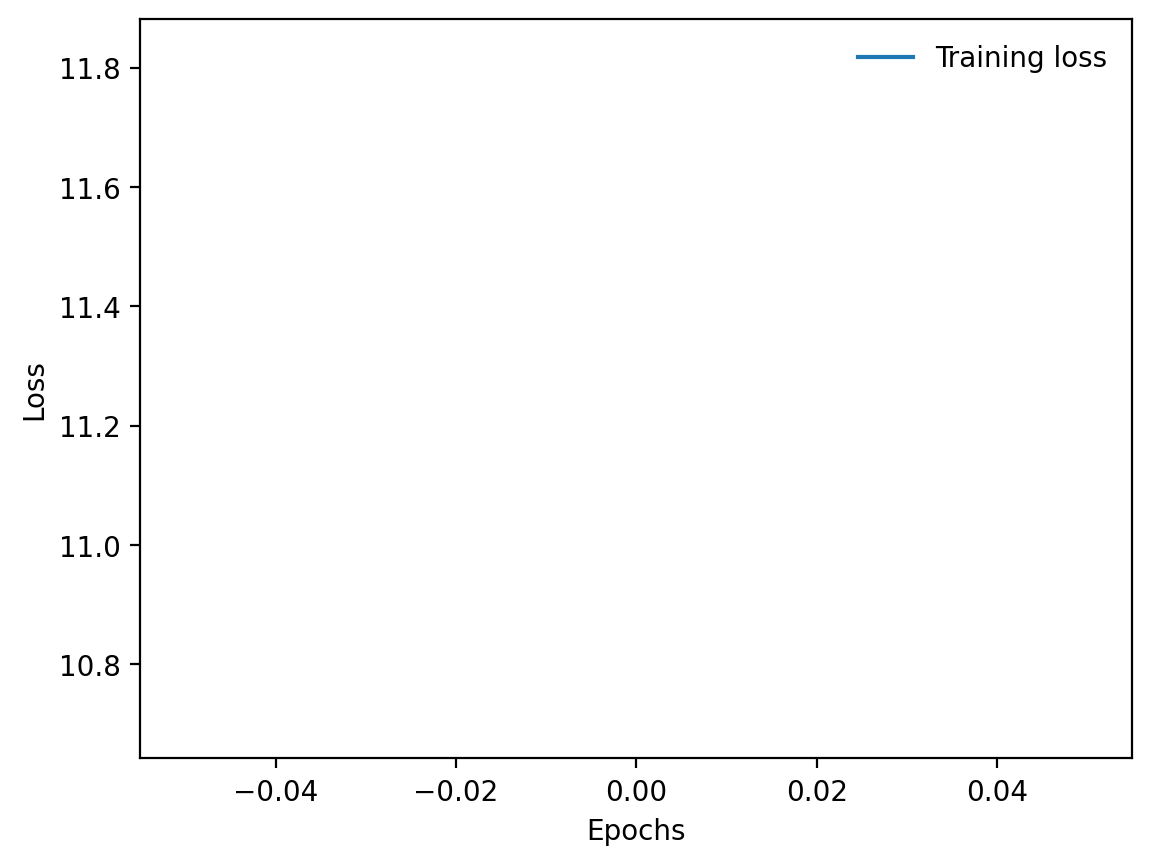

In [107]:
#%matplotlib inline
#%config InlineBackend.figure_format = 'retina'

plt.plot(train_losses, label='Training loss')
#plt.plot(valid_losses, label='Validation loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(frameon=False)

Funcion test

In [108]:
# Test

model.eval()  # se deshabilitan las capas de dropout
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
          
    print('Test Accuracy of the model: {} %'.format(100 * correct / total))

# Save 
torch.save(model.state_dict(), '11_cars_model.ckpt')

Test Accuracy of the model: 0.8456659619450317 %


Visualizar el resultado, se utiliza imagenes en test

In [109]:
# Funcion para visualizar las predicciones de test

def visualize_model(model, num_images):
    was_training = model.training
    
    model.eval()
    images_so_far = 0       
    
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
                    
            for j in range(inputs.size()[0]):
                images_so_far +=1
                ax = plt.subplot(num_images, 1, images_so_far)
                
                ax.axis('off')
                ax.set_title('Predicted: {} (Clase: {})'.format(class_names[preds[j]], class_names[labels[j]]))
                                
                imshow(inputs.cpu().data[j])
                
                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return           
                
        model.train(mode = was_training)


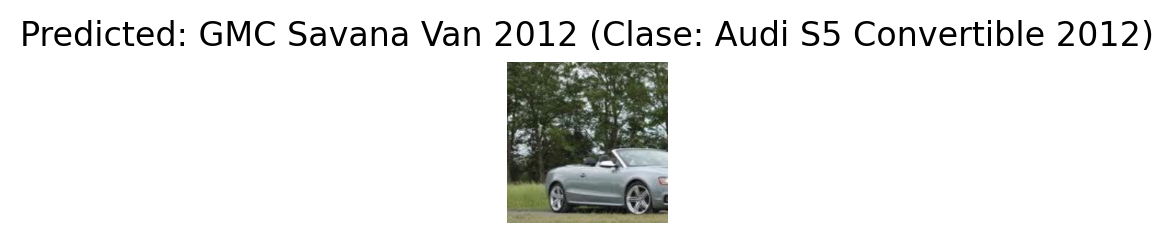

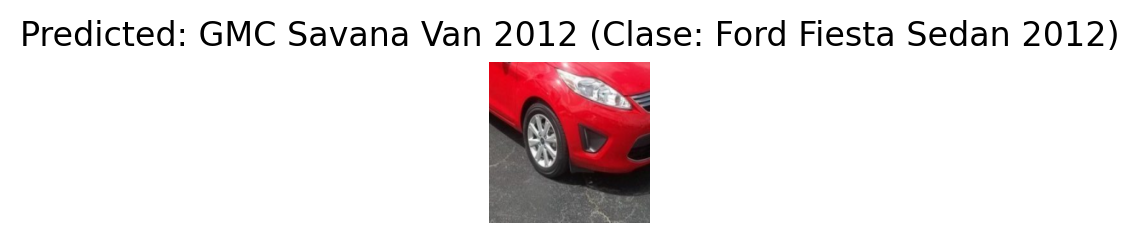

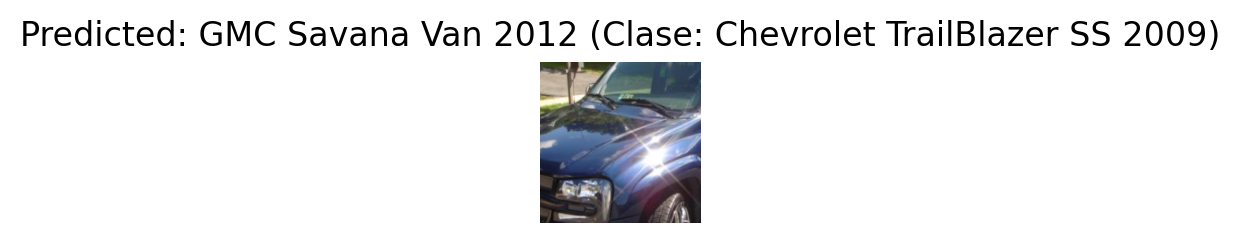

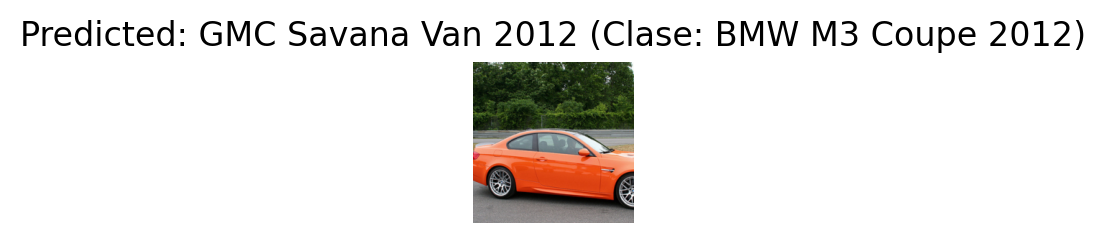

In [110]:
visualize_model(model=model, num_images = 4)